In [2]:
import pandas as pd

# Load the dataset
dataset_path = 'weatherHistory.csv'
weather_data = pd.read_csv(dataset_path)

# Display the first few rows of the dataset to understand its structure
weather_data.head()


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


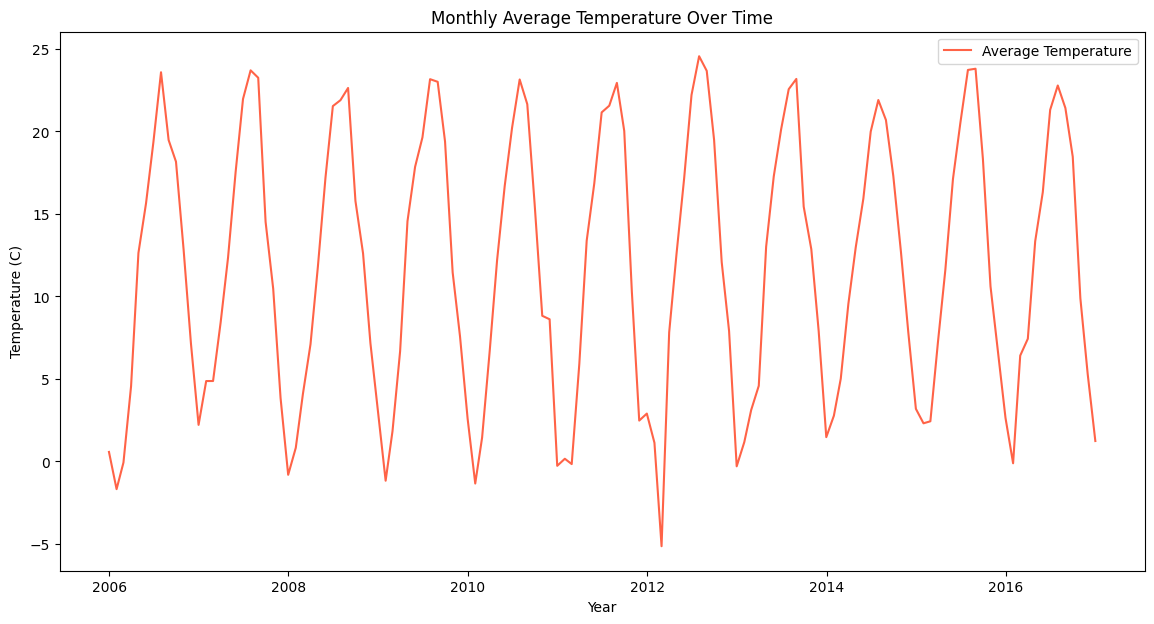

In [3]:
import matplotlib.pyplot as plt
# Convert 'Formatted Date' to datetime and set as index
weather_data['Formatted Date'] = pd.to_datetime(weather_data['Formatted Date'], utc=True)
weather_data.set_index('Formatted Date', inplace=True)

# Resample data to get monthly averages for temperature
monthly_temp_avg = weather_data['Temperature (C)'].resample('M').mean()

# Create a line plot for monthly average temperature
plt.figure(figsize=(14, 7))
plt.plot(monthly_temp_avg.index, monthly_temp_avg, label='Average Temperature', color='tomato')
plt.title('Monthly Average Temperature Over Time')
plt.xlabel('Year')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()







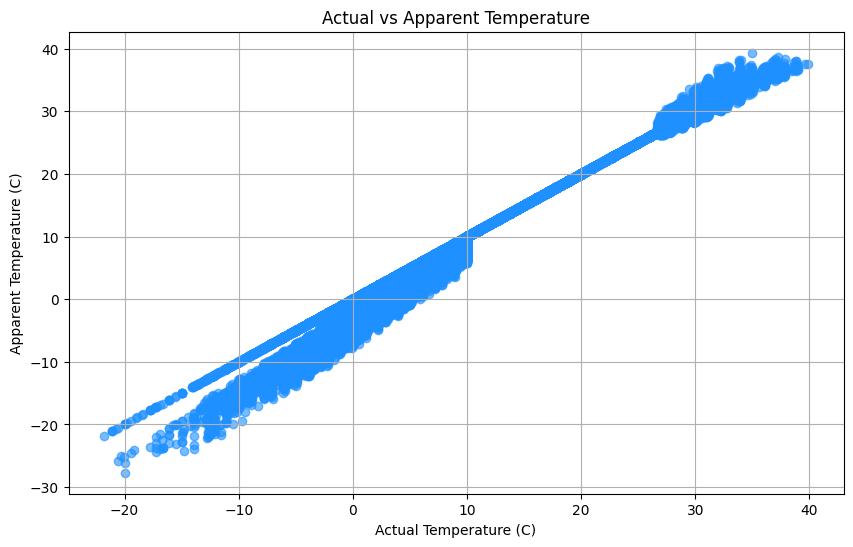

In [4]:
# Scatter plot to compare Actual vs Apparent Temperature
plt.figure(figsize=(10, 6))
plt.scatter(weather_data['Temperature (C)'], weather_data['Apparent Temperature (C)'], alpha=0.6, c='dodgerblue')
plt.title('Actual vs Apparent Temperature')
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Apparent Temperature (C)')
plt.grid(True)
plt.show()


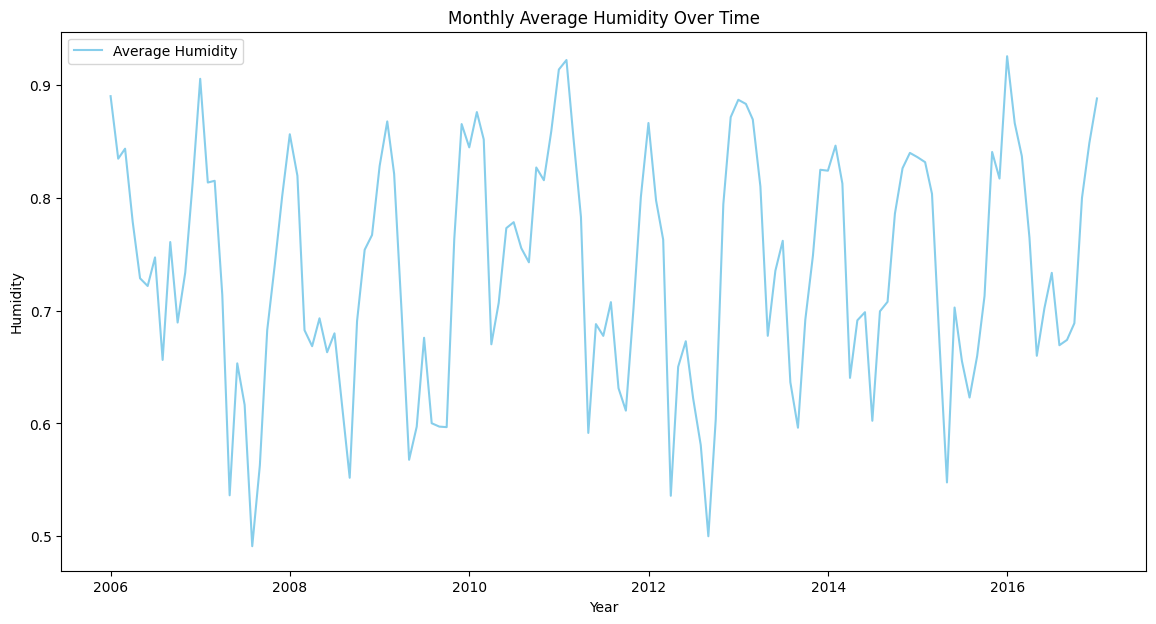

In [5]:
# Resample data to get monthly averages for humidity
monthly_humidity_avg = weather_data['Humidity'].resample('M').mean()

# Create a line plot for monthly average humidity
plt.figure(figsize=(14, 7))
plt.plot(monthly_humidity_avg.index, monthly_humidity_avg, label='Average Humidity', color='skyblue')
plt.title('Monthly Average Humidity Over Time')
plt.xlabel('Year')
plt.ylabel('Humidity')
plt.legend()
plt.show()


In [6]:


import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px

# Initialize the Dash app
app = dash.Dash(__name__)

# Prepare data for dropdown options
metrics = ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
options = [{'label': metric, 'value': metric} for metric in metrics]

app.layout = html.Div([
    html.H1("Weather Data Dashboard"),
    dcc.Dropdown(
        id='metric-selector',
        options=options,
        value='Temperature (C)'  # Default value
    ),
    dcc.DatePickerRange(
        id='date-picker-range',
        start_date=weather_data.index.min(),
        end_date=weather_data.index.max(),
        display_format='YYYY-MM-DD'
    ),
    dcc.Graph(id='weather-graph')
])

@app.callback(
    Output('weather-graph', 'figure'),
    [Input('metric-selector', 'value'),
     Input('date-picker-range', 'start_date'),
     Input('date-picker-range', 'end_date')]
)
def update_graph(selected_metric, start_date, end_date):
    # Filter data based on selected date range
    filtered_data = weather_data.loc[start_date:end_date]
    
    # Create a Plotly Express graph for the selected metric
    fig = px.line(filtered_data, y=selected_metric, title=f'Monthly Average {selected_metric}')
    
    return fig

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True)


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Attempting seasonal decomposition with a shorter cycle of 90 days (approximately a quarter)
decomposition_short = seasonal_decompose(weather_data.dropna(), model='additive', period=180)

# Plotting the decomposed components of the time series with a shorter cycle
plt.figure(figsize=(14, 10))

# Trend component
plt.subplot(411)
plt.plot(decomposition_short.trend, label='Trend', color='blue')
plt.legend(loc='upper left')
plt.xlabel('Date')
plt.ylabel('Trend')

# Seasonal component
plt.subplot(412)
plt.plot(decomposition_short.seasonal.iloc[:180], label='Seasonality', color='green')  # Plotting half a year of seasonality for clarity
plt.legend(loc='upper left')
plt.xlabel('Date')
plt.ylabel('Seasonality')

# Residual component
plt.subplot(413)
plt.plot(decomposition_short.resid, label='Residuals', color='red')
plt.legend(loc='upper left')
plt.xlabel('Date')
plt.ylabel('Residuals')

# Original Time Series for reference
plt.subplot(414)
plt.plot(weather_data, label='Original', color='cyan')
plt.legend(loc='upper left')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')

plt.tight_layout()
plt.show()


ValueError: could not convert string to float: 'Partly Cloudy'

In [9]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the data is in the expected format and frequency
if not monthly_temp_avg.index.is_monotonic_increasing:
    monthly_temp_avg = monthly_temp_avg.sort_index()

# Check for sufficient data points
if len(monthly_temp_avg.dropna()) < 2 * 90:  # At least two cycles
    raise ValueError("Not enough data points for the specified period of 90 days.")

try:
    # Seasonal decomposition
    decomposition_short = seasonal_decompose(monthly_temp_avg.dropna(), model='additive', period=90)

    # Plotting
    plt.figure(figsize=(14, 10))

    # Trend
    plt.subplot(411)
    plt.plot(decomposition_short.trend, label='Trend', color='blue')
    plt.legend(loc='upper left')
    plt.xlabel('Date')
    plt.ylabel('Trend')

    # Seasonality
    plt.subplot(412)
    plt.plot(decomposition_short.seasonal.iloc[:180], label='Seasonality', color='green')  # First 180 days
    plt.legend(loc='upper left')
    plt.xlabel('Date')
    plt.ylabel('Seasonality')

    # Residuals
    plt.subplot(413)
    plt.plot(decomposition_short.resid, label='Residuals', color='red')
    plt.legend(loc='upper left')
    plt.xlabel('Date')
    plt.ylabel('Residuals')

    # Original Time Series
    plt.subplot(414)
    plt.plot(monthly_temp_avg, label='Original', color='cyan')
    plt.legend(loc='upper left')
    plt.xlabel('Date')
    plt.ylabel('Temperature (C)')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")


ValueError: Not enough data points for the specified period of 90 days.